# EuroSAT Land Use Classification with ResNet50

Classify Sentinel-2 satellite image patches into 10 land use classes using transfer learning with ResNet50.

## 1. Configuration

In [1]:
import os
import random
import numpy as np
import torch

# --- Paths ---
# Kaggle
DATA_DIR = "/kaggle/input/datasets/marwanmesbah19/eurosat-rgb-1/EuroSAT_RGB"
# Local:
# DATA_DIR = "../Dataset/EuroSAT_RGB"

OUTPUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Hyperparameters ---
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
NUM_CLASSES = 10
SEED = 42
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
PATIENCE = 12

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print(f"Device: {DEVICE}")
print(f"Mixed precision: {USE_AMP}")

# --- Reproducibility ---
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

Device: cuda
Mixed precision: True


## 2. Imports

In [2]:
import copy
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, SubsetRandomSampler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

## 3. Data Loading and Preprocessing

In [3]:
# Training augmentations — designed for satellite imagery
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Validation/test transforms — deterministic
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [4]:
# Load dataset and create train/val/test splits
full_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes
dataset_size = len(full_dataset)

print(f"Classes ({len(class_names)}): {class_names}")
print(f"Total images: {dataset_size}")

# Shuffle and split indices
indices = list(range(dataset_size))
np.random.shuffle(indices)

train_end = int(TRAIN_SPLIT * dataset_size)
val_end = int((TRAIN_SPLIT + VAL_SPLIT) * dataset_size)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

# Create datasets with appropriate transforms
train_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=SubsetRandomSampler(train_idx),
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        sampler=SubsetRandomSampler(val_idx),
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         sampler=SubsetRandomSampler(test_idx),
                         num_workers=2, pin_memory=True)

Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000
Train: 18900 | Val: 4050 | Test: 4050


## 4. Dataset Visualization

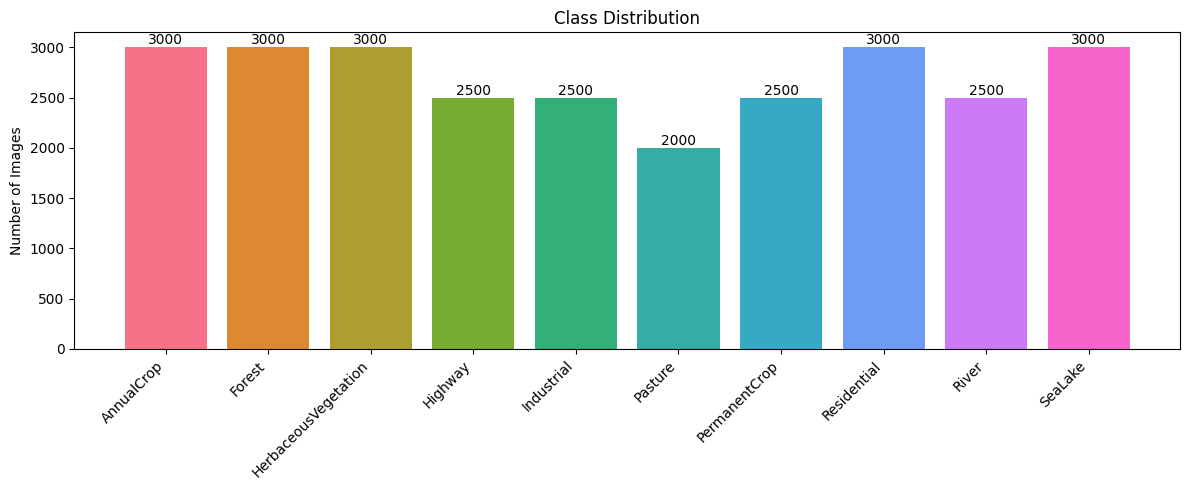

In [5]:
# Class distribution
class_counts = [0] * len(class_names)
for _, label in full_dataset:
    class_counts[label] += 1

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_names, class_counts, color=sns.color_palette("husl", len(class_names)))
ax.set_ylabel("Number of Images")
ax.set_title("Class Distribution")
plt.xticks(rotation=45, ha="right")
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(count), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=150)
plt.show()

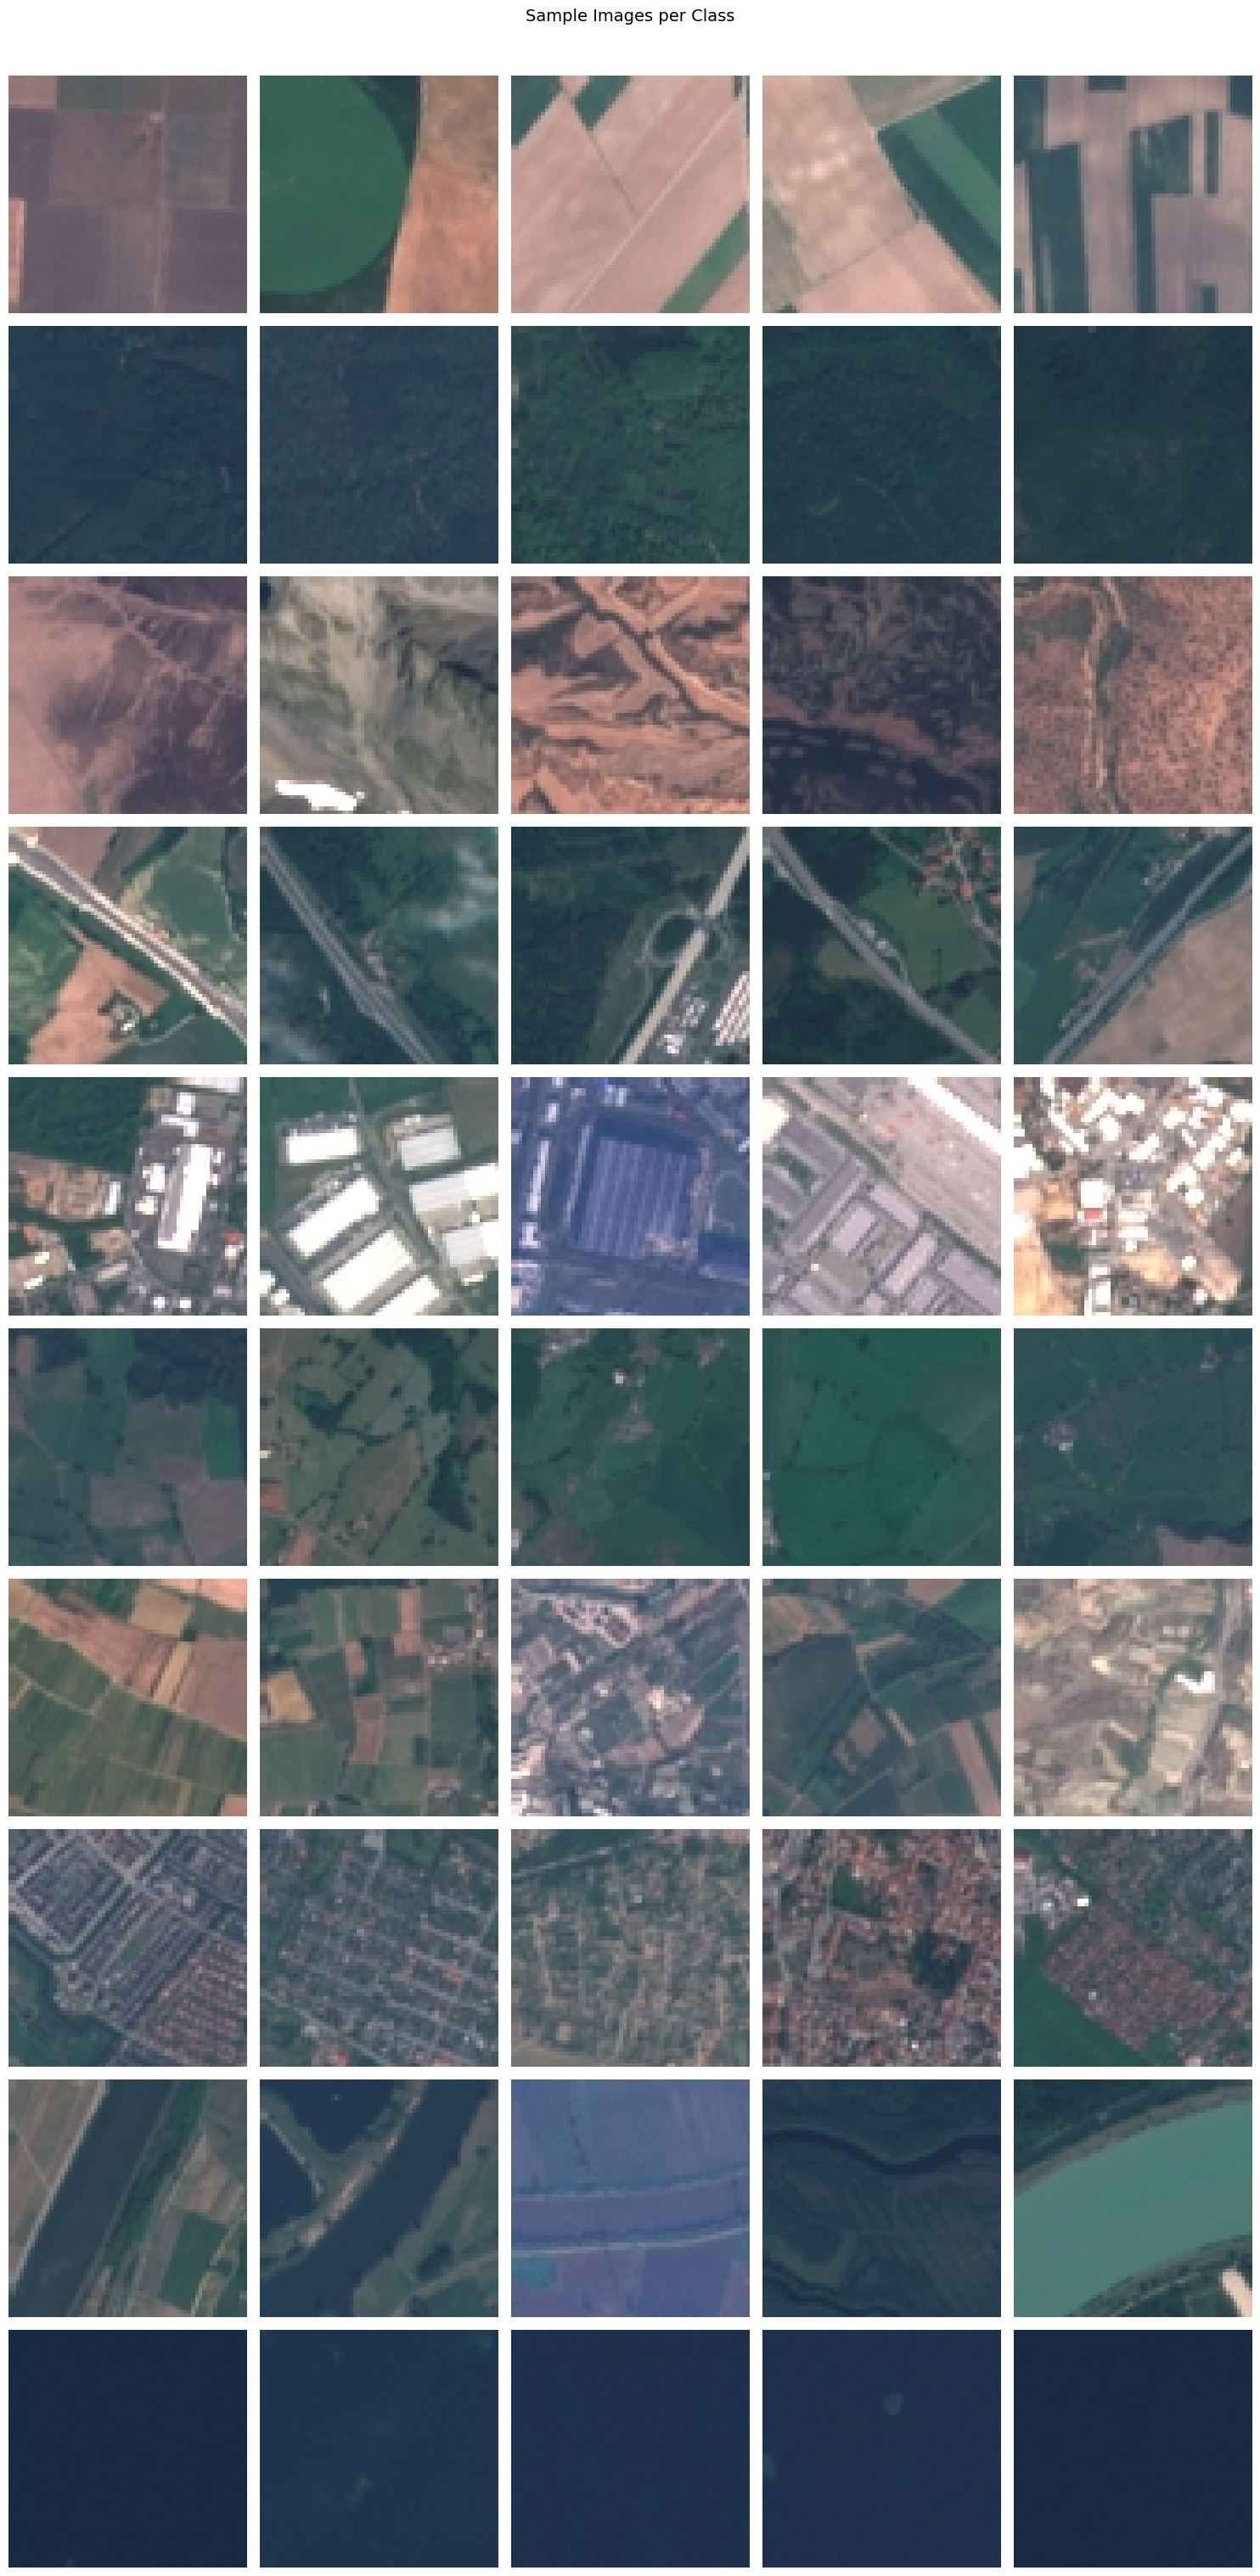

In [7]:
# Sample images from each class
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

fig, axes = plt.subplots(len(class_names), 5, figsize=(15, 30))
samples_per_class = {}
for img, label in full_dataset:
    name = class_names[label]
    if name not in samples_per_class:
        samples_per_class[name] = []
    if len(samples_per_class[name]) < 5:
        samples_per_class[name].append(img)
    if len(samples_per_class) == len(class_names) and all(len(v) == 5 for v in samples_per_class.values()):
        break

for i, cls in enumerate(class_names):
    for j in range(5):
        axes[i, j].imshow(samples_per_class[cls][j])
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=10, rotation=0, labelpad=60)
plt.suptitle("Sample Images per Class", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_images.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Model Definition

In [8]:
# --- ResNet50 built from scratch ---

class Bottleneck(nn.Module):
    """ResNet50 bottleneck block: 1x1 → 3x3 → 1x1 with skip connection."""
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                               kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNet50(nn.Module):
    """ResNet50 manually implemented from scratch."""

    def __init__(self, num_classes=10):
        super().__init__()

        # Stem
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual layers
        self.layer1 = self._make_layer(64, 64, blocks=3, stride=1)
        self.layer2 = self._make_layer(256, 128, blocks=4, stride=2)
        self.layer3 = self._make_layer(512, 256, blocks=6, stride=2)
        self.layer4 = self._make_layer(1024, 512, blocks=3, stride=2)

        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels * Bottleneck.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * Bottleneck.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * Bottleneck.expansion),
            )

        layers = [Bottleneck(in_channels, out_channels, stride, downsample)]
        for _ in range(1, blocks):
            layers.append(Bottleneck(out_channels * Bottleneck.expansion, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# Create model
model = ResNet50(num_classes=NUM_CLASSES).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 23,528,522
Trainable parameters: 23,528,522


## 6. Optimizer, Scheduler, and Loss

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

## 7. Training Loop

In [11]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc = 0.0
best_model_wts = None
patience_counter = 0

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # --- Training ---
    model.train()
    running_loss, running_corrects, total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = running_corrects / total

    # --- Validation ---
    model.eval()
    val_loss, val_corrects, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_corrects / val_total
    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    elapsed = time.time() - start_time

    # --- Record history ---
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] {elapsed:.0f}s | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}")

    # --- Checkpoint ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "class_names": class_names,
        }, os.path.join(OUTPUT_DIR, "best_resnet50_eurosat.pth"))
        patience_counter = 0
        print(f"  -> New best model saved (val_acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Starting training...



Epoch [1/100] 116s | Train Loss: 1.2513 Acc: 0.5517 | Val Loss: 0.7875 Acc: 0.7180 | LR: 0.000300
  -> New best model saved (val_acc: 0.7180)


Epoch [2/100] 118s | Train Loss: 0.8197 Acc: 0.7094 | Val Loss: 1.5523 Acc: 0.5753 | LR: 0.000300


Epoch [3/100] 115s | Train Loss: 0.6239 Acc: 0.7867 | Val Loss: 0.7358 Acc: 0.7442 | LR: 0.000300
  -> New best model saved (val_acc: 0.7442)


Epoch [4/100] 116s | Train Loss: 0.4795 Acc: 0.8386 | Val Loss: 0.5993 Acc: 0.7948 | LR: 0.000299
  -> New best model saved (val_acc: 0.7948)


...

Epoch [67/100] 115s | Train Loss: 0.0379 Acc: 0.9860 | Val Loss: 0.0754 Acc: 0.9760 | LR: 0.000078


Epoch [68/100] 118s | Train Loss: 0.0358 Acc: 0.9869 | Val Loss: 0.0720 Acc: 0.9775 | LR: 0.000074


Epoch [69/100] 119s | Train Loss: 0.0367 Acc: 0.9867 | Val Loss: 0.0728 Acc: 0.9765 | LR: 0.000070


Epoch [70/100] 117s | Train Loss: 0.0333 Acc: 0.9888 | Val Loss: 0.0690 Acc: 0.9768 | LR: 0.000066


Epoch [71/100] 121s | Train Loss: 0.0329 Acc: 0.9873 | Val Loss: 0.0703 Acc: 0.9770 | LR: 0.000063

Early stopping at epoch 71

Best validation accuracy: 0.9798


## 8. Training Curves

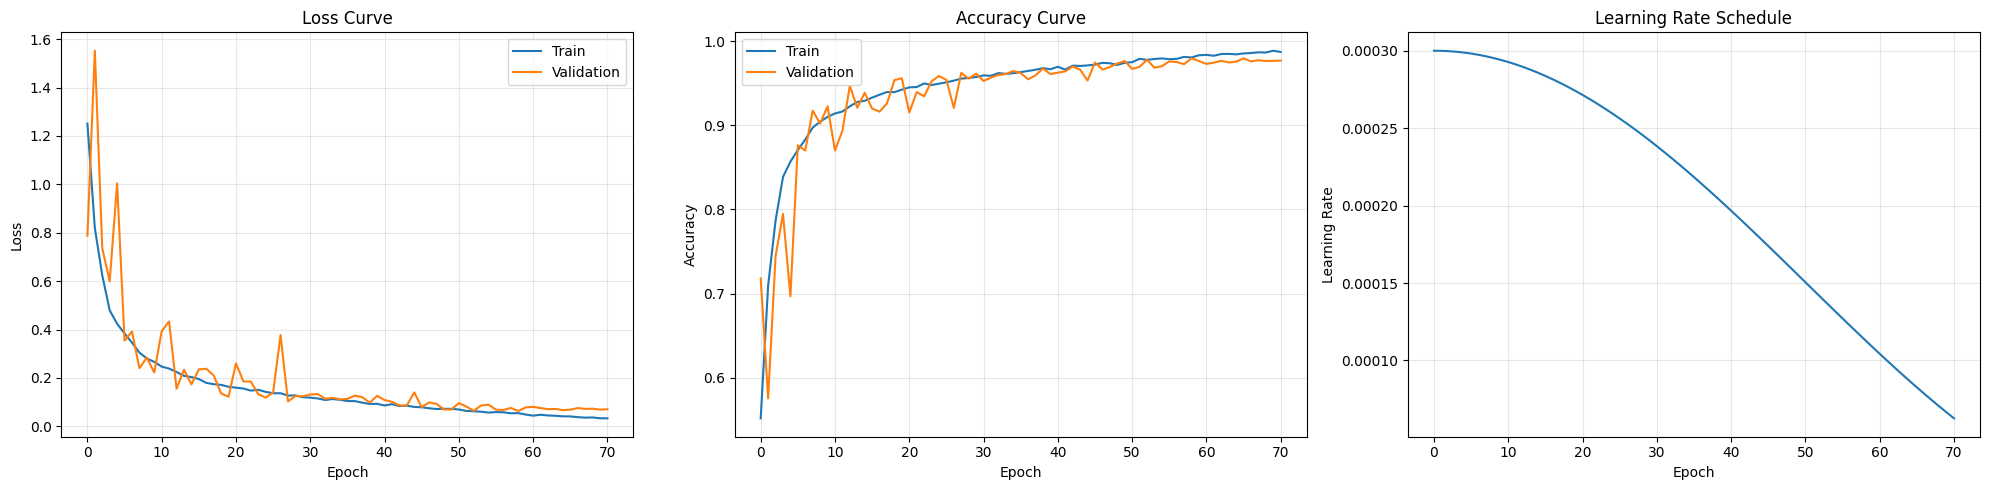

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Loss
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history["lr"])
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()

## 9. Test Evaluation

In [19]:
# Load best model
model.load_state_dict(best_model_wts)
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(DEVICE)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            outputs = model(inputs)

        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Metrics
test_acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Macro F1:       {macro_f1:.4f}")
print(f"Weighted F1:    {weighted_f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

Testing: 100%|██████████| 64/64 [00:07<00:00,  8.49it/s]

Test Accuracy:  0.9765
Macro F1:       0.9759
Weighted F1:    0.9766

                      precision    recall  f1-score   support

          AnnualCrop     0.9663    0.9795    0.9729       439
              Forest     0.9866    0.9888    0.9877       447
HerbaceousVegetation     0.9608    0.9564    0.9586       436
             Highway     0.9709    0.9813    0.9761       374
          Industrial     0.9920    0.9763    0.9841       380
             Pasture     0.9700    0.9664    0.9682       268
       PermanentCrop     0.9508    0.9607    0.9557       382
         Residential     0.9930    0.9860    0.9895       430
               River     0.9762    0.9762    0.9762       420
             SeaLake     0.9936    0.9873    0.9905       474

            accuracy                         0.9765      4050
           macro avg     0.9760    0.9759    0.9759      4050
        weighted avg     0.9766    0.9765    0.9766      4050



## 10. Confusion Matrix

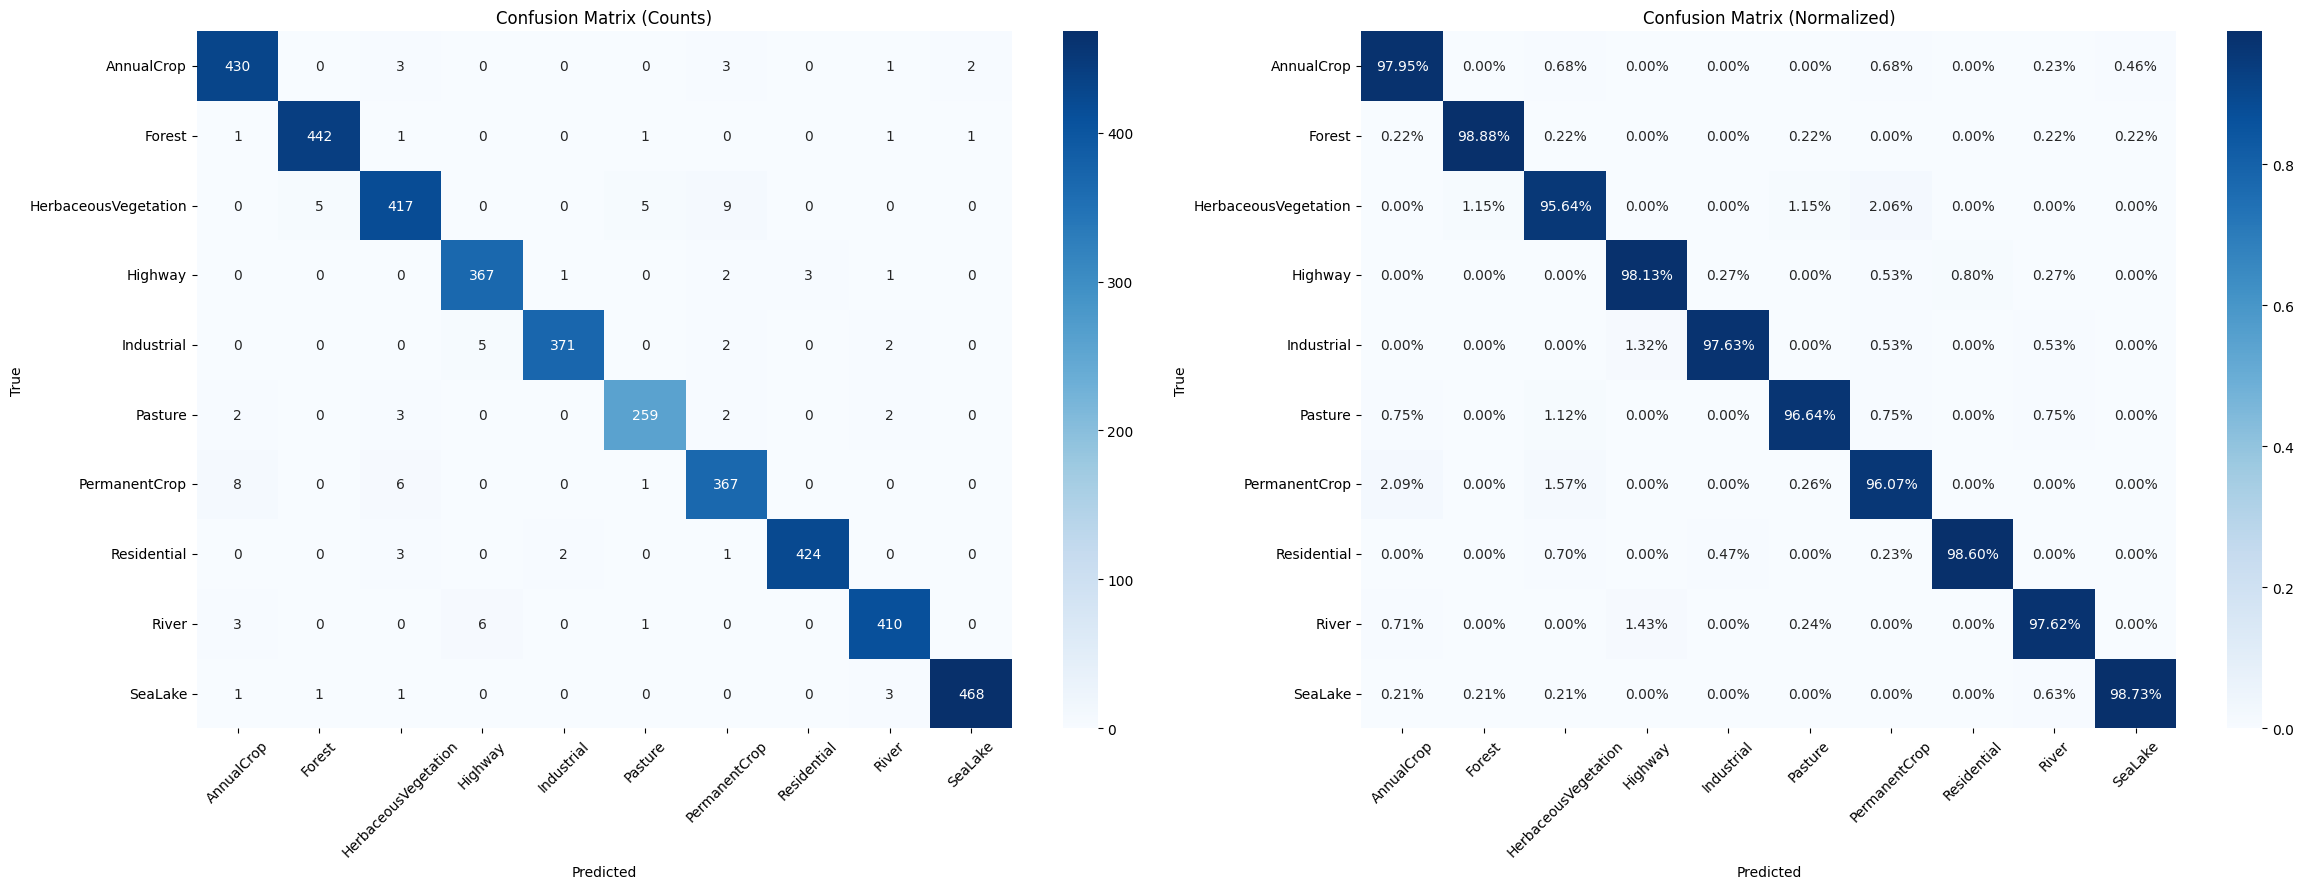

In [20]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(24, 9))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

## 11. Per-Class Accuracy

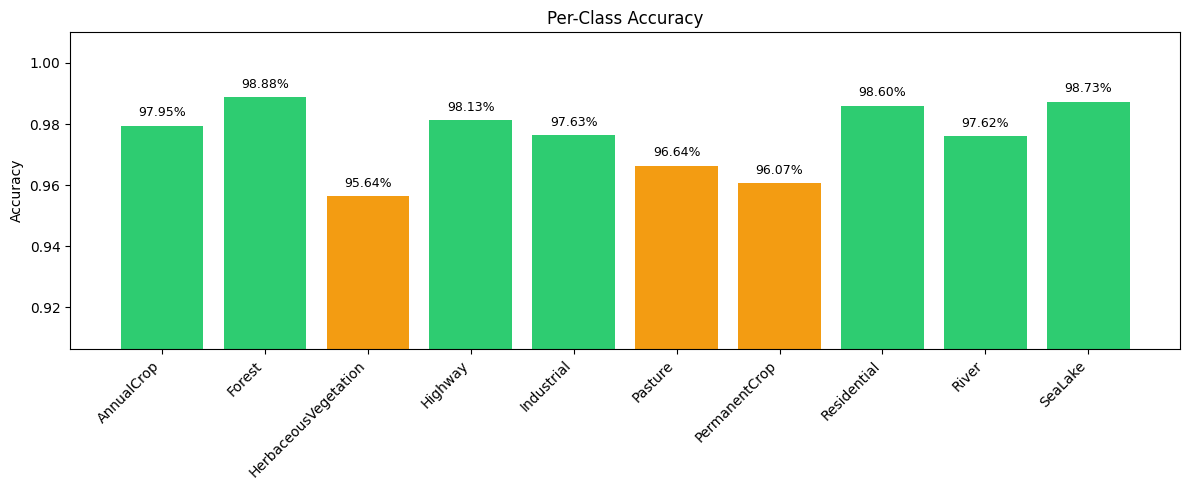

In [21]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2ecc71" if acc >= 0.97 else "#e74c3c" if acc < 0.93 else "#f39c12" for acc in per_class_acc]
bars = ax.bar(class_names, per_class_acc, color=colors)
ax.set_ylim(min(per_class_acc) - 0.05, 1.01)
ax.set_ylabel("Accuracy")
ax.set_title("Per-Class Accuracy")
plt.xticks(rotation=45, ha="right")

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{acc:.2%}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_accuracy.png"), dpi=150)
plt.show()

## 12. Sample Predictions

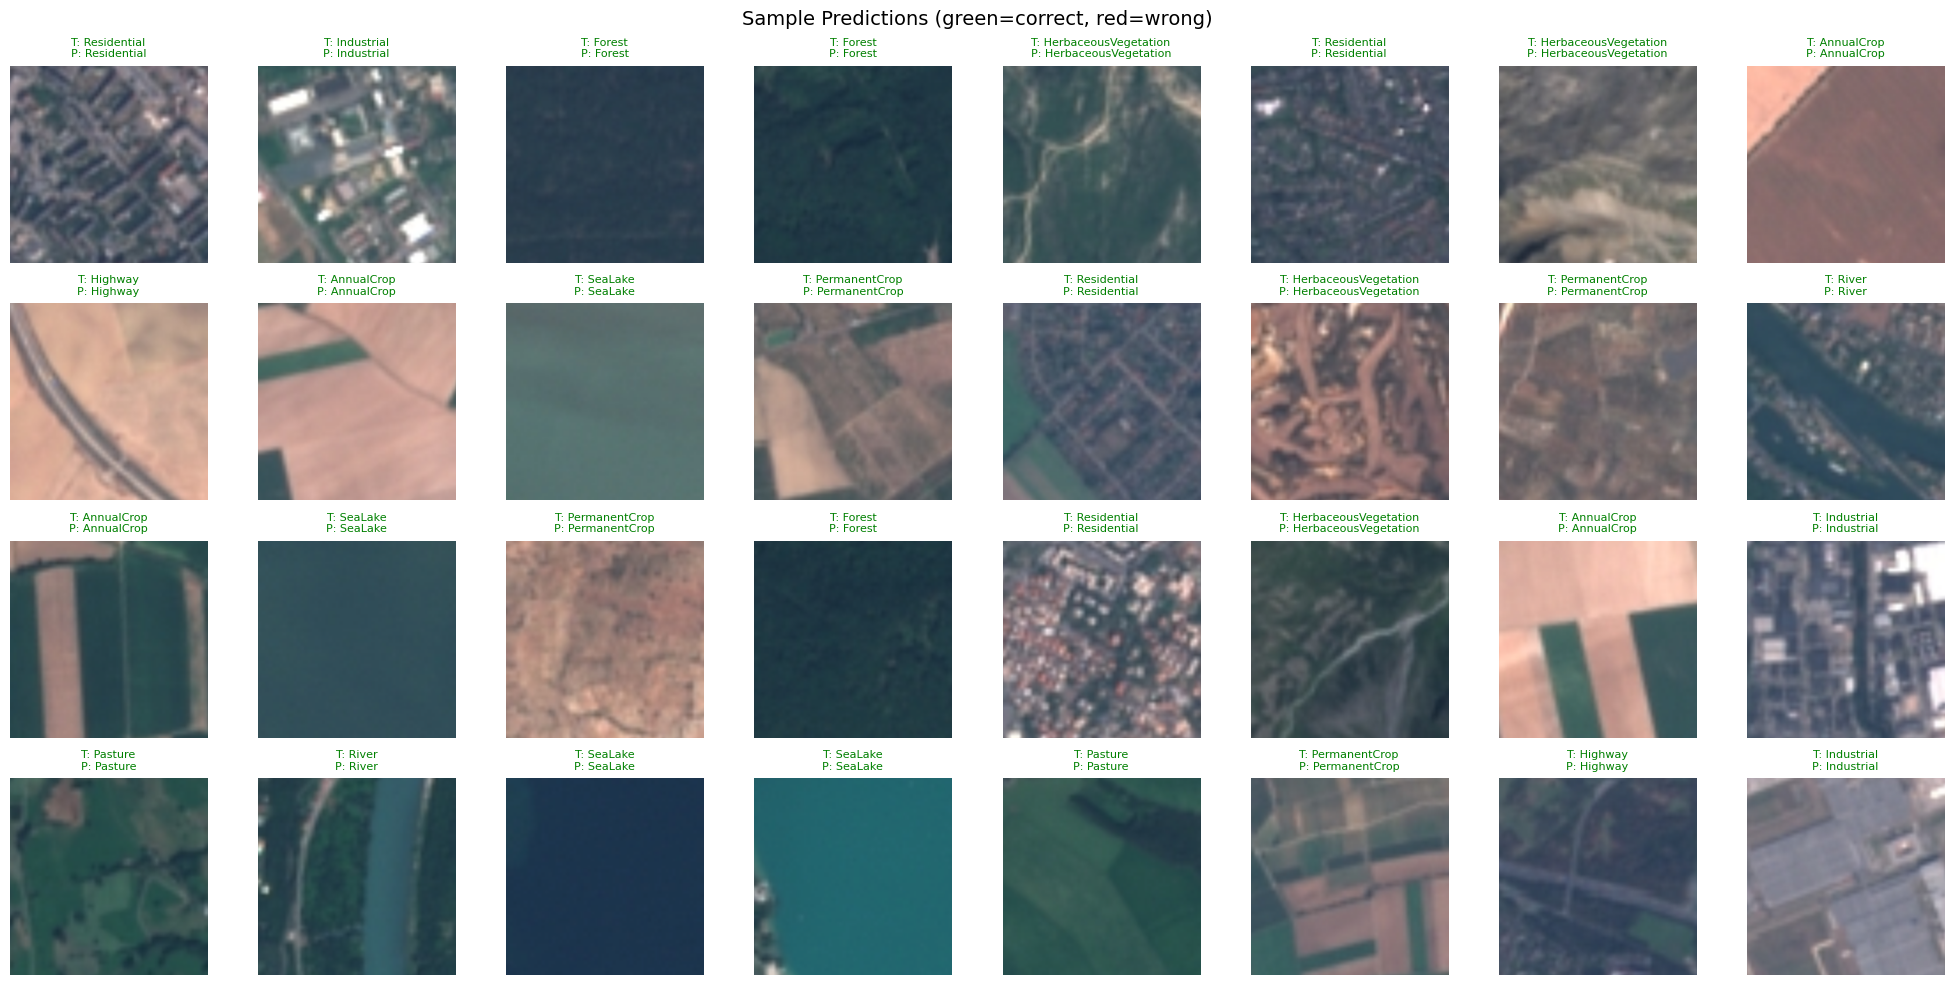

In [22]:
# Show test images with predictions
model.eval()
images_shown, num_rows, num_cols = 0, 4, 8

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 10))

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs_gpu = inputs.to(DEVICE)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            outputs = model(inputs_gpu)
        _, preds = torch.max(outputs, 1)

        for i in range(inputs.size(0)):
            if images_shown >= num_rows * num_cols:
                break

            row, col = images_shown // num_cols, images_shown % num_cols
            img = inv_normalize(inputs[i]).permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)

            true_name = class_names[labels[i]]
            pred_name = class_names[preds[i].item()]
            correct = true_name == pred_name

            axes[row, col].imshow(img)
            axes[row, col].set_title(
                f"T: {true_name}\nP: {pred_name}",
                fontsize=8, color="green" if correct else "red"
            )
            axes[row, col].axis("off")
            images_shown += 1

        if images_shown >= num_rows * num_cols:
            break

plt.suptitle("Sample Predictions (green=correct, red=wrong)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_predictions.png"), dpi=150)
plt.show()

## 13. Save Final Artifacts

In [23]:
# Save final model
torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "resnet50_eurosat_final.pth"))

# Save classification report as CSV
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).T
report_df.to_csv(os.path.join(OUTPUT_DIR, "classification_report.csv"))

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index_label="epoch")

print("Saved:")
print(f"  - resnet50_eurosat_final.pth")
print(f"  - classification_report.csv")
print(f"  - training_history.csv")
print(f"  - best_resnet50_eurosat.pth (best checkpoint)")

Saved:
  - resnet50_eurosat_final.pth
  - classification_report.csv
  - training_history.csv
  - best_resnet50_eurosat.pth (best checkpoint)
